In [498]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings('ignore')

# Data analysis, cleaning and visualisation

In [499]:
data = pd.read_csv('data/Fish.csv')
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
display(data.head())
display(data.describe())

Shape: (159, 7)
Columns: ['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [500]:
print("Sum of all Nan values for each column:")
data.isna().sum()

Sum of all Nan values for each column:


Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [501]:
print("Sum of entries for each species:")
data_sp = data.Species.value_counts()
data_sp.T

Sum of entries for each species:


Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

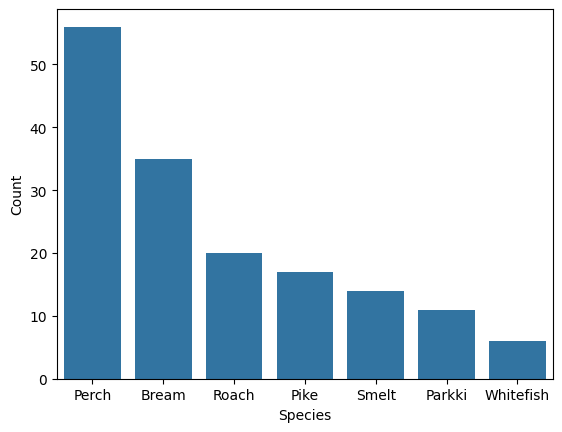

In [502]:
sns.barplot(x = data_sp.index, y = data_sp)
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

In [503]:
zero_weight_indices = data[data.Weight <= 0].index[0]
data.drop(index=zero_weight_indices, inplace=True)

In [504]:
print("Data shape after removing zero weight indices:", data.shape)

Data shape after removing zero weight indices: (158, 7)


In [505]:
# Correlation check 
# Veca korelacija izmedju nezavisnih promenljivih cini estimacije nepouzdanijim 
data.corr(numeric_only=True)

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.915719,0.918603,0.923090,0.723857,0.886654
Length1,0.915719,1.000000,0.999516,0.992004,0.624409,0.866684
Length2,0.918603,0.999516,1.000000,0.994083,0.639503,0.873201
Length3,0.923090,0.992004,0.994083,1.000000,0.702655,0.878189
Height,0.723857,0.624409,0.639503,0.702655,1.000000,0.792401
Width,0.886654,0.866684,0.873201,0.878189,0.792401,1.000000


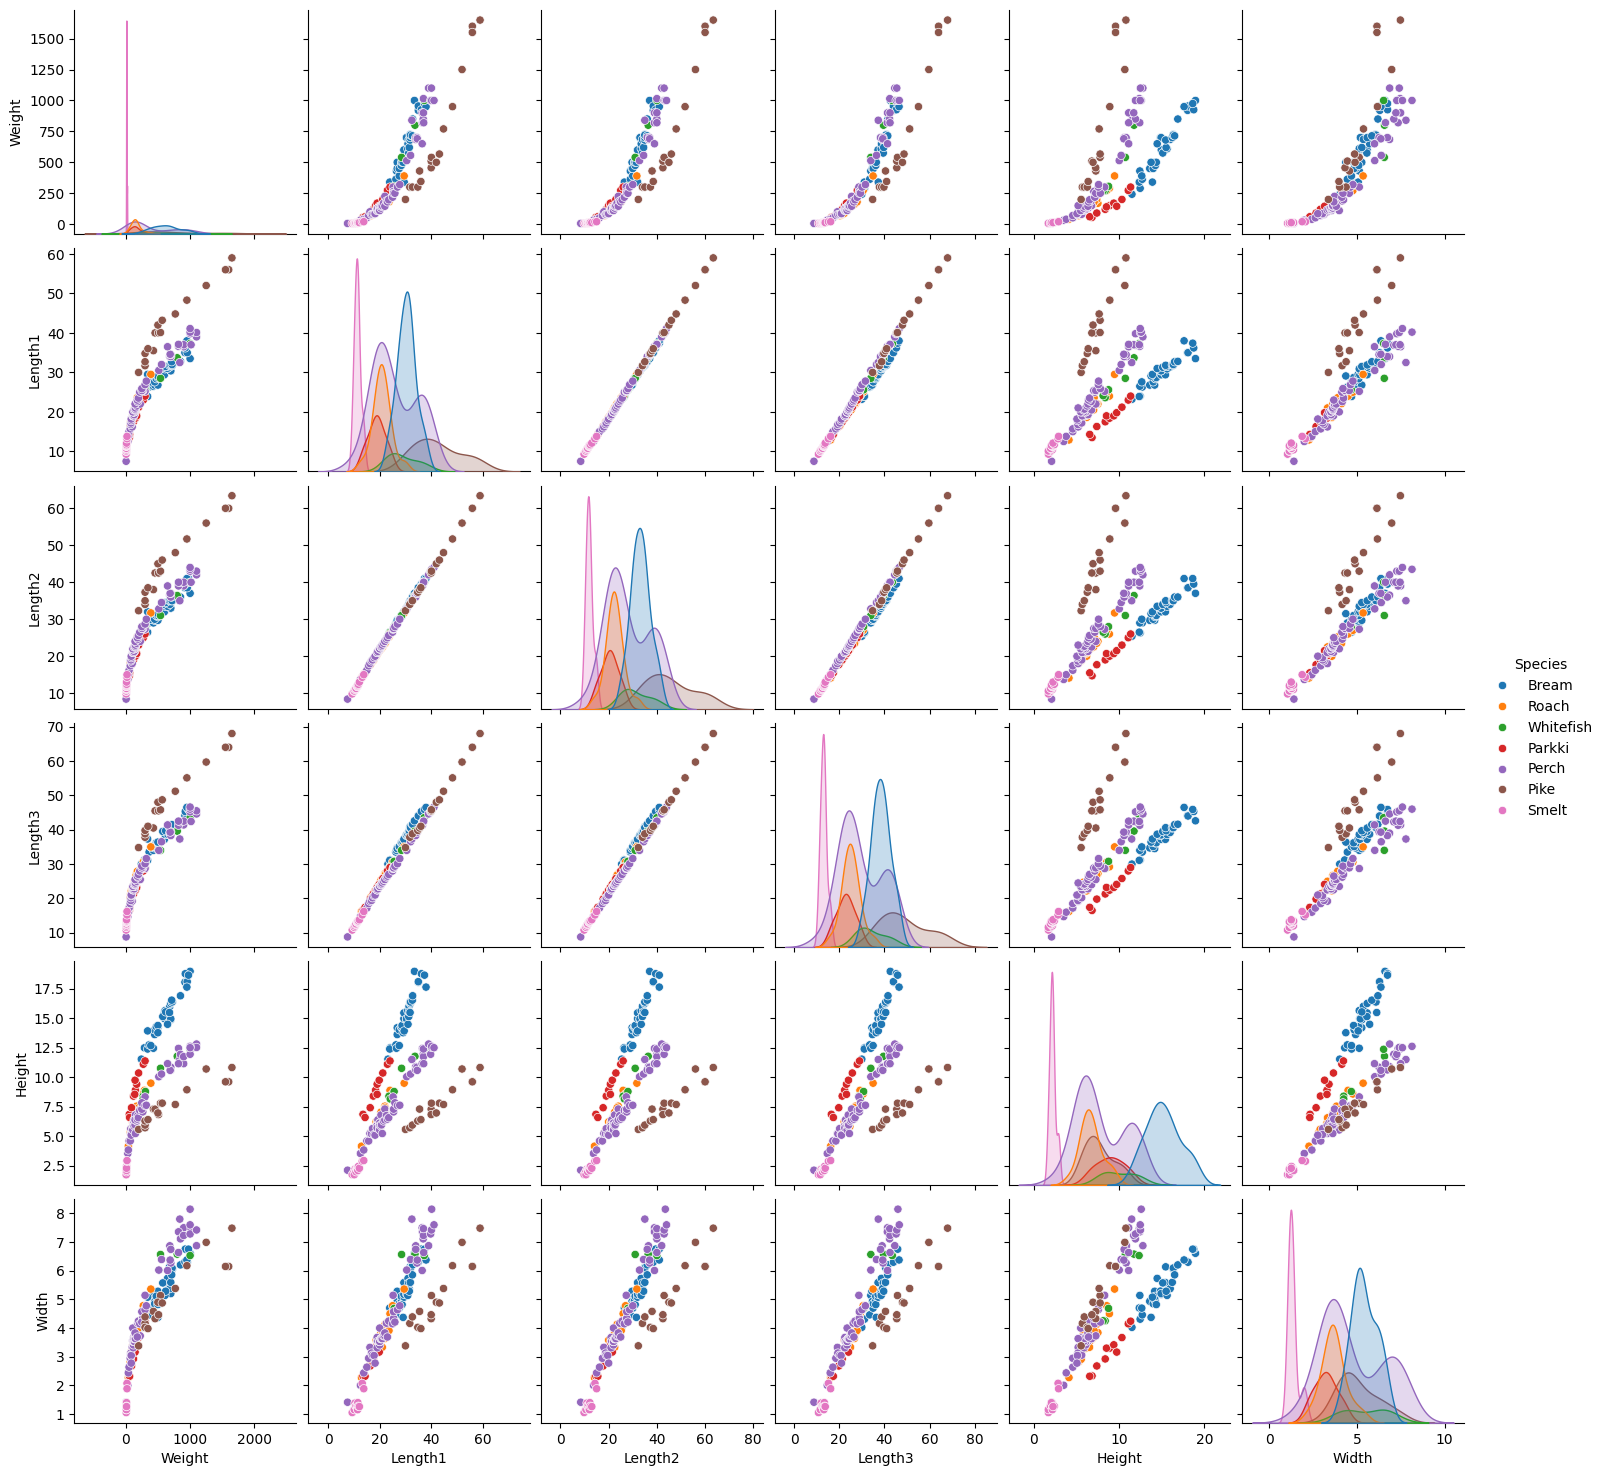

In [506]:
sns.pairplot(data, kind = "scatter", hue = "Species")

<Axes: >

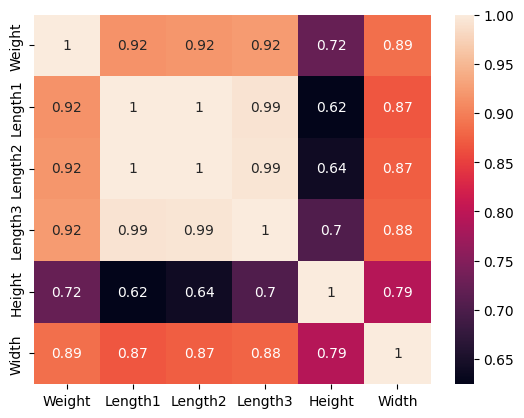

In [507]:
# Matrica korelacije 
sns.heatmap(data.corr(numeric_only=True), annot=True)

Length1, Length2 i Lenght3 imaju veliku korelaciju medjusobom, ali i sa ciljnom promenljivom Weight, te ako bi se primenjivala multivarijabilna regresija sa ovim atributima trebalo bi razmotriti koriscenje samo jednog od njih. 

### Detekcija odudarajućih podataka

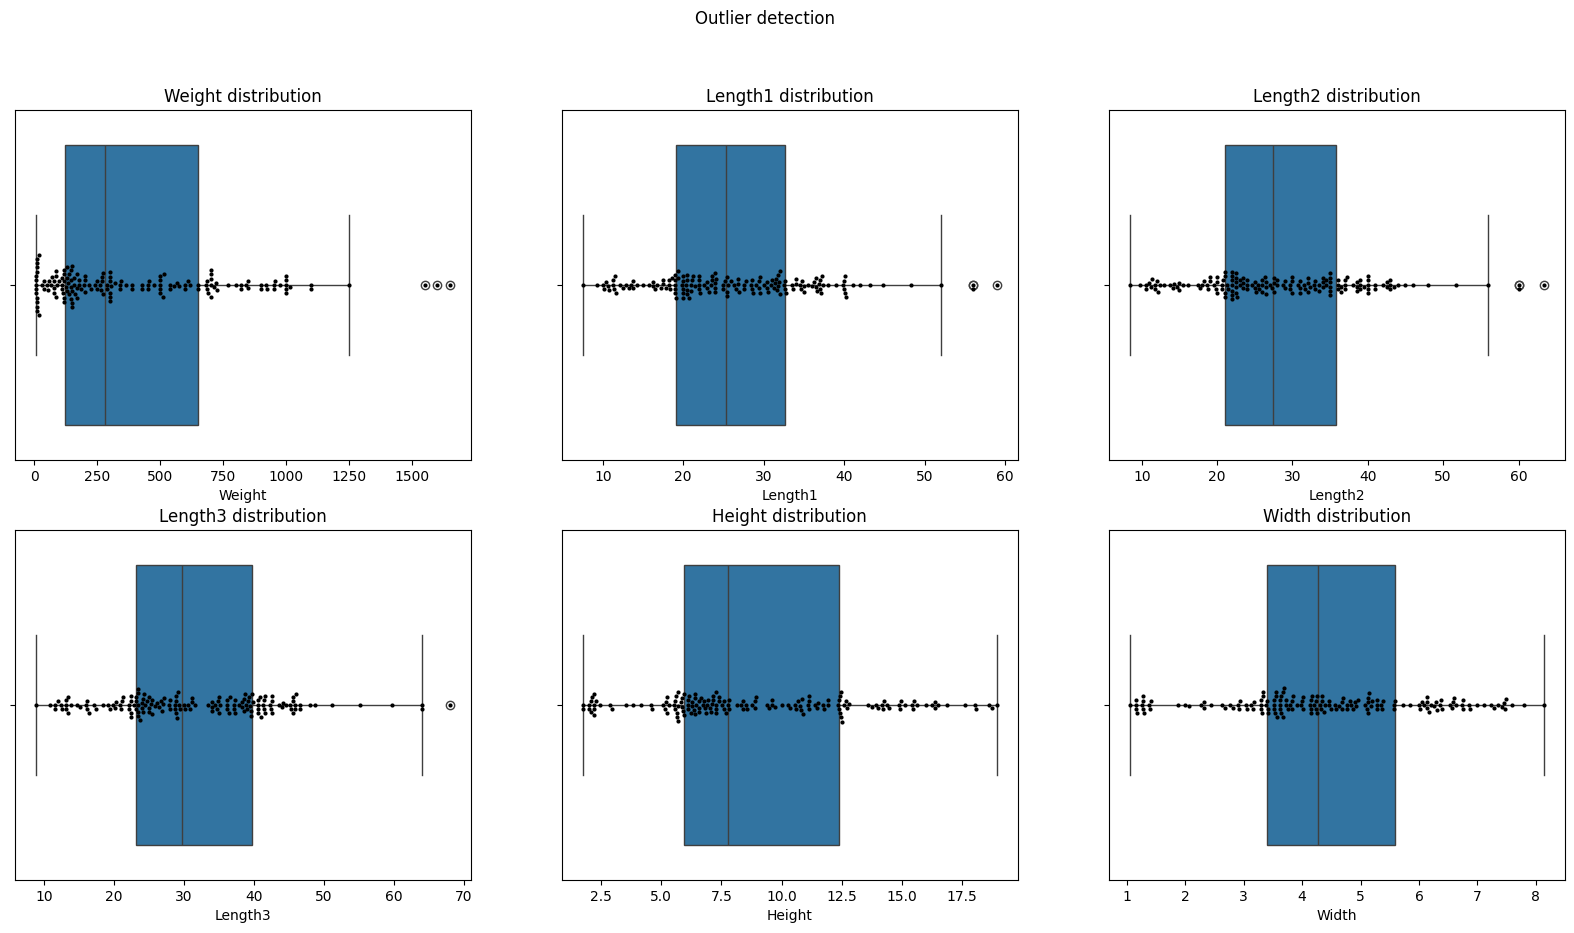

In [510]:
plt.figure(figsize = (20, 10))

for i, j in enumerate(data.select_dtypes(include = "number").columns.to_list()):
        plt.subplot(2, 3, i + 1)
        sns.boxplot(data = data, x = j)
        sns.swarmplot(data = data, x = j, color = "k", size = 3)
        plt.title(f"{j} distribution")
plt.suptitle("Outlier detection")
plt.show()

Nije dovoljno samo razmatrati pojedinacne kolone, jer individualne mere mogu izgledati normalno, ali njihove kombinacije mogu biti neobicne

In [511]:
# IQR on residuals
def outlier_detection(residuals):
    Q1 = residuals.quantile(0.25)
    Q3 = residuals.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR 
    return [(residuals < lower_bound) | (residuals > upper_bound), lower_bound, upper_bound]


In [522]:
#X = data[["Length", "Width", "Height"]]
X = np.log(data[["Length1","Length2","Length3", "Width", "Height"]])
#y = data["Weight"]
y = np.log(data["Weight"])
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

residuals = y - y_pred

outlier_mask, lower_bound, upper_bound = outlier_detection(residuals)

outliers = data[outlier_mask]

print("Number of outliers in original data based on IQR on residuals:", len(outliers))
print(outliers)

Number of outliers in original data based on IQR on residuals: 5
    Species  Weight  Length1  Length2  Length3   Height   Width
13    Bream   340.0     29.5     32.0     37.3  13.9129  5.0728
96    Perch   225.0     22.0     24.0     25.5   7.2930  3.7230
142    Pike  1600.0     56.0     60.0     64.0   9.6000  6.1440
157   Smelt    19.7     13.2     14.3     15.2   2.8728  2.0672
158   Smelt    19.9     13.8     15.0     16.2   2.9322  1.8792


Text(0.5, 1.0, 'Residual Plot')

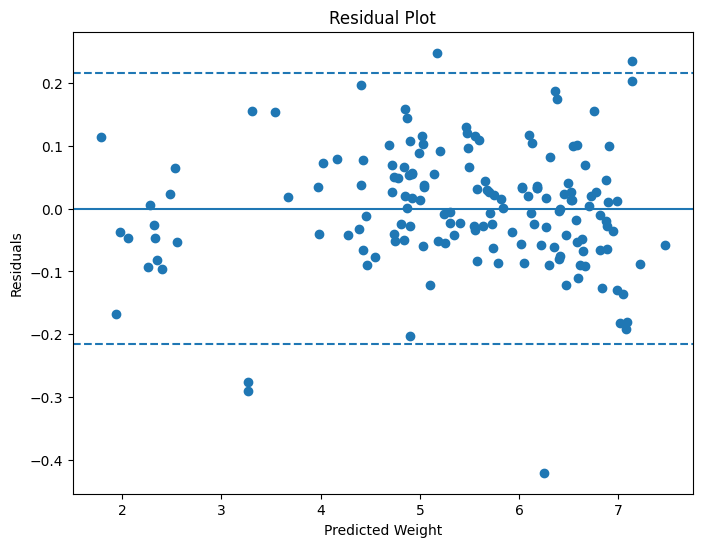

In [523]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(upper_bound, linestyle='--')
plt.axhline(lower_bound, linestyle='--')
plt.axhline(0)

plt.xlabel("Predicted Weight")
plt.ylabel("Residuals")
plt.title("Residual Plot")

In [524]:
def print_outlier_detection_by_attribute(data, attr):
    outlier_indices_attr, _, _ = outlier_detection(data[attr])
    print(f"Outlier detection based on {attr}:")
    print(data[outlier_indices_attr])

In [525]:
print_outlier_detection_by_attribute(data, "Weight")
print_outlier_detection_by_attribute(data, "Length1")
print_outlier_detection_by_attribute(data, "Length2")
print_outlier_detection_by_attribute(data, "Length3")
print_outlier_detection_by_attribute(data, "Height")
print_outlier_detection_by_attribute(data, "Width")

Outlier detection based on Weight:
    Species  Weight  Length1  Length2  Length3  Height  Width
142    Pike  1600.0     56.0     60.0     64.0   9.600  6.144
143    Pike  1550.0     56.0     60.0     64.0   9.600  6.144
144    Pike  1650.0     59.0     63.4     68.0  10.812  7.480
Outlier detection based on Length1:
    Species  Weight  Length1  Length2  Length3  Height  Width
142    Pike  1600.0     56.0     60.0     64.0   9.600  6.144
143    Pike  1550.0     56.0     60.0     64.0   9.600  6.144
144    Pike  1650.0     59.0     63.4     68.0  10.812  7.480
Outlier detection based on Length2:
    Species  Weight  Length1  Length2  Length3  Height  Width
142    Pike  1600.0     56.0     60.0     64.0   9.600  6.144
143    Pike  1550.0     56.0     60.0     64.0   9.600  6.144
144    Pike  1650.0     59.0     63.4     68.0  10.812  7.480
Outlier detection based on Length3:
    Species  Weight  Length1  Length2  Length3  Height  Width
144    Pike  1650.0     59.0     63.4     68.0  10.

Ovo se poklapa sa boxplot grafikom, ali se ne poklapa sa rezultatima IQR metode (osim za liniju 142).

Veza između dužine L i težine W kod većine vrste riba se može izraziti kao $W=cL^b$, gde b približno 3.0 kod većine vrsta. Očigledno, ova veza nije linearna te primenom logaritamske transformacije dobijamo $log(W)=log(c)\cdot b\cdot log(L)$, što je zapravo $Y=\beta_0+\beta_1\cdot X$.

Zbog ovoga je vršena logaritmaska transofrmacija podataka prilikom računanja reziduala: eliminisali smo lažne outliere koji si su javljali kao posledica pogrešne pretpostavke o linearnosti. 

Detekcija outlier podataka je bila informativna. Dakle, nećemo ovakve podatke eliminisati jer se bavimo tehnikama robusne regresije.

In [526]:
# imamo dve opcije 
# radimo prostu regresiju tako sto imitiramo atribute zapremine Volume = Length * Width * Height
# ili radimo prostu regresiju sa svakim od atributa ponaosob i uporedjujemo rezultate